## Conditional Generation of Fashion Images!(Get over Classification)
Used Conditional GAN for image generation. Basically you tell the model to give Shoes and the model develops a new Shoe that does not exist. We are teaching the model to think uniquely.

Easy Notebook in Keras

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/fashionmnist/train-images-idx3-ubyte
/kaggle/input/fashionmnist/fashion-mnist_train.csv
/kaggle/input/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/fashionmnist/fashion-mnist_test.csv


In [2]:
from keras.datasets.fashion_mnist import load_data
from keras.layers import Conv2D,LeakyReLU,Flatten,Dense,Reshape,Conv2DTranspose,Dropout,Input,Embedding,Concatenate
from keras.optimizers import Adam
from keras.models import Sequential,load_model,Model
from matplotlib import pyplot

In [3]:
(trainX,trainY),(testX,testY)=load_data()
print(trainX.shape,trainY.shape)
print(testX.shape,testY.shape)

4423680/4422102 [==============================] - 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


## Overview of type of Images

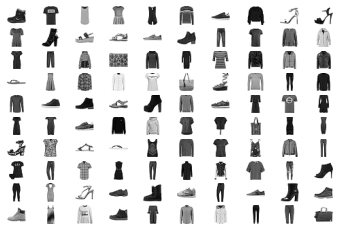

In [4]:
for i in range(100):
    # define subplot
    pyplot.subplot(10, 10, 1 + i)
    # turn off axis
    pyplot.axis('off')
    # plot raw pixel data
    pyplot.imshow(trainX[i], cmap='gray_r')
pyplot.show()

## Lets define the Discriminator
A Simple CNN Architecture. Helps to distinguish between real and fake images.

In [5]:
def discriminatorModel(inp_shape=(28,28,1),n_classes=10):
    in_label=Input(shape=(1,))
    li=Embedding(n_classes,50)(in_label)
    n_nodes=inp_shape[0]*inp_shape[1]
    li=Dense(n_nodes)(li)
    li=Reshape((inp_shape[0],inp_shape[1],1))(li)
    in_image=Input(shape=inp_shape)
    merge=Concatenate()([in_image,li])
  
    fe=Conv2D(128,(3,3),strides=(2,2),padding="same")(merge)
    fe=LeakyReLU(alpha=0.2)(fe)

    fe=Conv2D(128,(3,3),strides=(2,2),padding="same")(merge)
    fe=LeakyReLU(alpha=0.2)(fe)

    fe=Flatten()(fe)
    fe=Dropout(0.4)(fe)
    out_layer=Dense(1,activation='sigmoid')(fe)

    model=Model([in_image,in_label],out_layer)
    opt = Adam(lr=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

## Lets Define the Generator
We have to train this model to create an image that can easily fool the generator. Notice here that I have not compiled the model. This is because it is trained along with the Discriminator

In [6]:
def generatorModel(latent_dim,n_classes=10):
    in_label=Input(shape=(1,))
    li=Embedding(n_classes,50)(in_label)
    n_nodes=7*7
    li=Dense(n_nodes)(li)
    li=Reshape((7,7,1))(li)
    in_lat=Input(shape=(latent_dim,))

    n_nodes=(128*7*7)
    gen=Dense(n_nodes)(in_lat)
    gen=LeakyReLU(alpha=0.2)(gen)
    gen = Reshape((7, 7, 128))(gen)

    merge = Concatenate()([gen, li])
    gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(merge)
    gen = LeakyReLU(alpha=0.2)(gen)

    gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(gen)
    gen = LeakyReLU(alpha=0.2)(gen)

    out_layer = Conv2D(1, (7,7), activation='tanh', padding='same')(gen)

    model = Model([in_lat, in_label], out_layer)  
    return model

## Here we Stack up both the Models and Define our GAN

In [7]:
def define_gan(generator,discriminator):
    discriminator.trainable=False
    model=Sequential()
    gen_noise,gen_label=generator.input
    gen_output = generator.output
    gan_output = discriminator([gen_output, gen_label])
    model = Model([gen_noise, gen_label], gan_output)
    opt = Adam(lr=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt)
    return model

## GAN takes up data from something called a Latent Space
We need to train Generator to pick up appropriate points from the Latent(Imaginary) Space. this is basically a random distribution

In [8]:
def load_real_samples():
    (trainX,trainY),(_,_)=load_data()
    X=np.expand_dims(trainX,axis=-1)
    X=X.astype('float32')
    X = (X - 127.5) / 127.5
    return [X,trainY]

In [9]:
def generate_real_samples(dataset,n_samples):
    images,labels=dataset
    ix=np.random.randint(0,images.shape[0],n_samples)
    X,labels=images[ix],labels[ix]
    Y=np.ones((n_samples,1))
    return [X,labels],Y

In [10]:
def generate_latent_points(latent_dim,n_samples,n_classes=10):
    x_input=np.random.randn(latent_dim*n_samples)
    z_input = x_input.reshape(n_samples, latent_dim)
    labels = np.random.randint(0, n_classes, n_samples)
    return [z_input, labels]

In [11]:
def generate_fake_samples(generator,latent_dim,n_samples):
    z_input,labels=generate_latent_points(latent_dim,n_samples)
    images=generator.predict([z_input,labels])
    Y=np.zeros((n_samples,1))
    return [images,labels],Y

## Compiling Everything to train the Generator!

In [12]:
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=5, n_batch=128):
    bat_per_epo = int(dataset[0].shape[0] / n_batch)
    half_batch = int(n_batch / 2)
    # manually enumerate epochs
    for i in range(n_epochs):
        # enumerate batches over the training set
        for j in range(bat_per_epo):
            # get randomly selected 'real' samples
            [X_real,labels_real], y_real = generate_real_samples(dataset, half_batch)
            # update discriminator model weights
            d_loss1, _ = d_model.train_on_batch([X_real,labels_real], y_real)
            # generate 'fake' examples
            [X_fake, labels], y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
            # update discriminator model weights
            d_loss2, _ = d_model.train_on_batch([X_fake, labels], y_fake)
            # prepare points in latent space as input for the generator
            [z_input, labels_input] = generate_latent_points(latent_dim, n_batch)
            # create inverted labels for the fake samples
            y_gan = np.ones((n_batch, 1))
            # update the generator via the discriminator's error
            g_loss = gan_model.train_on_batch([z_input, labels_input], y_gan)
            # summarize loss on this batch
            print('>%d, %d/%d, d1=%.3f, d2=%.3f g=%.3f' %
                (i+1, j+1, bat_per_epo, d_loss1, d_loss2, g_loss))
    # save the generator model
    g_model.save('generator.h5')

## This takes some time on CPU. Try Enabling your GPU

In [13]:
latent_dim=100
discriminator=discriminatorModel()
generator=generatorModel(latent_dim)
gan_model=define_gan(generator,discriminator)
dataset=load_real_samples()
train(generator,discriminator,gan_model,dataset,latent_dim)

>1, 1/468, d1=0.704, d2=0.694 g=0.693
>1, 2/468, d1=0.580, d2=0.700 g=0.687
>1, 3/468, d1=0.496, d2=0.711 g=0.677
>1, 4/468, d1=0.425, d2=0.728 g=0.660
>1, 5/468, d1=0.378, d2=0.753 g=0.638
>1, 6/468, d1=0.313, d2=0.787 g=0.615
>1, 7/468, d1=0.285, d2=0.825 g=0.589
>1, 8/468, d1=0.269, d2=0.868 g=0.575
>1, 9/468, d1=0.237, d2=0.884 g=0.586
>1, 10/468, d1=0.245, d2=0.846 g=0.630
>1, 11/468, d1=0.277, d2=0.765 g=0.720
>1, 12/468, d1=0.278, d2=0.653 g=0.840
>1, 13/468, d1=0.270, d2=0.552 g=0.974
>1, 14/468, d1=0.324, d2=0.481 g=1.063
>1, 15/468, d1=0.267, d2=0.445 g=1.092
>1, 16/468, d1=0.300, d2=0.471 g=1.026
>1, 17/468, d1=0.223, d2=0.527 g=0.923
>1, 18/468, d1=0.266, d2=0.595 g=0.819
>1, 19/468, d1=0.309, d2=0.659 g=0.743
>1, 20/468, d1=0.281, d2=0.728 g=0.679
>1, 21/468, d1=0.220, d2=0.803 g=0.625
>1, 22/468, d1=0.239, d2=0.878 g=0.586
>1, 23/468, d1=0.187, d2=0.909 g=0.589
>1, 24/468, d1=0.192, d2=0.887 g=0.637
>1, 25/468, d1=0.149, d2=0.794 g=0.733
>1, 26/468, d1=0.121, d2=0.693 g=0

In [14]:
def save_plot(examples, n):
    # plot images
    for i in range(n * n):
        # define subplot
        pyplot.subplot(n, n, 1 + i)
        # turn off axis
        pyplot.axis('off')
        # plot raw pixel data
        pyplot.imshow(examples[i, :, :, 0], cmap='gray_r')
    pyplot.show()

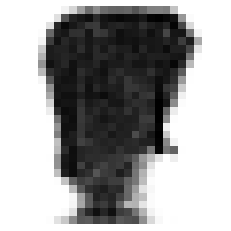

In [15]:
model = load_model('generator.h5')
# generate images
latent_points, labels = generate_latent_points(100, 100)
# specify labels
labels = np.asarray([x for _ in range(10) for x in range(10)])
# generate images
X  = model.predict([latent_points, labels])
# scale from [-1,1] to [0,1]
X = (X + 1) / 2.0
# plot the result
save_plot(X, 1)